In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
names = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(url, names= names)

In [47]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [49]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [50]:
len(df.columns)

14

In [51]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


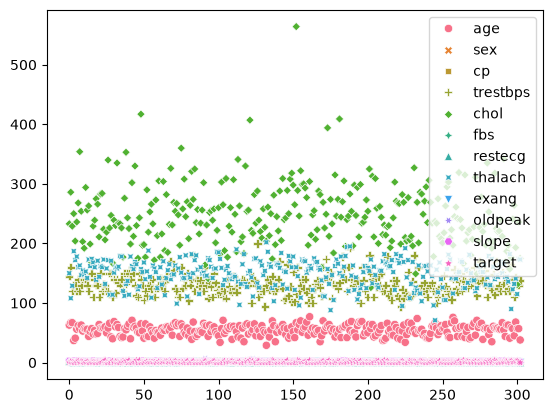

In [52]:
__ = sns.scatterplot(data=df)

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df["ca"].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

In [55]:
df = df.replace("?", np.nan)
df = df.apply(pd.to_numeric)
df = df.fillna(df.median())

In [56]:
df["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [57]:
df["target"] = np.where(df["target"] > 0, 1,0)

In [58]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [59]:
X = df.drop(columns="target")
y = df["target"]

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, stratify=y, random_state=42)

In [62]:
X_train.shape

(242, 13)

In [63]:
y_train.shape

(242,)

In [64]:
# GridSearchCV result : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

In [65]:
# RandomizedSearchCV result : {'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 193}

In [89]:
rf = RandomForestClassifier(n_estimators=193, max_depth=None, min_samples_split=6, random_state=42)

In [90]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",193
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [91]:
y_pred = rf.predict(X_test)

In [92]:
from sklearn.metrics import classification_report

In [93]:
report = classification_report(y_test, y_pred)

In [94]:
print(report)

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [72]:
importance = rf.feature_importances_

In [73]:
importance

array([0.06079386, 0.03930594, 0.14090659, 0.0557367 , 0.05721581,
       0.00599005, 0.01217409, 0.11205695, 0.06300719, 0.09446431,
       0.04289083, 0.11647455, 0.19898313])

In [74]:
type(importance)

numpy.ndarray

In [75]:
feat_imp = pd.Series(importance,index=X.columns).sort_values(ascending=False)

In [76]:
feat_imp.head(3)

thal    0.198983
cp      0.140907
ca      0.116475
dtype: float64

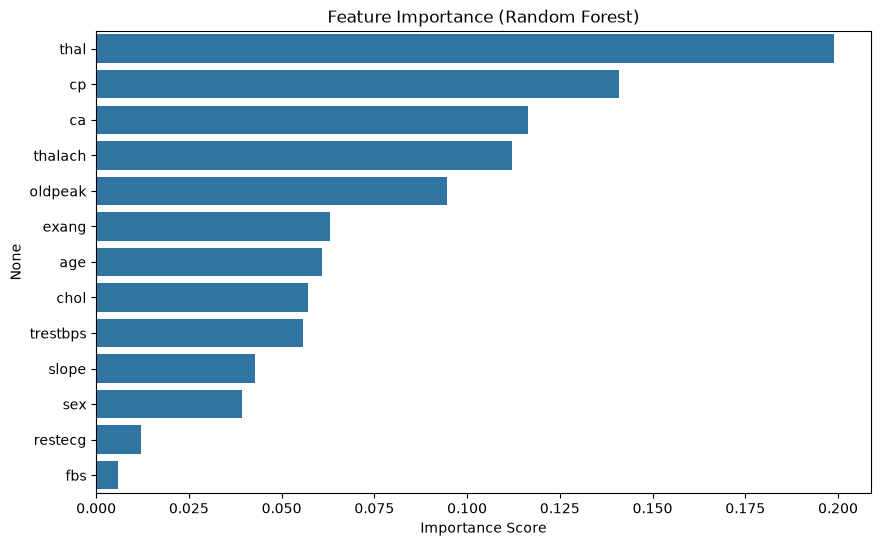

In [77]:
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

In [78]:
from sklearn.metrics import confusion_matrix

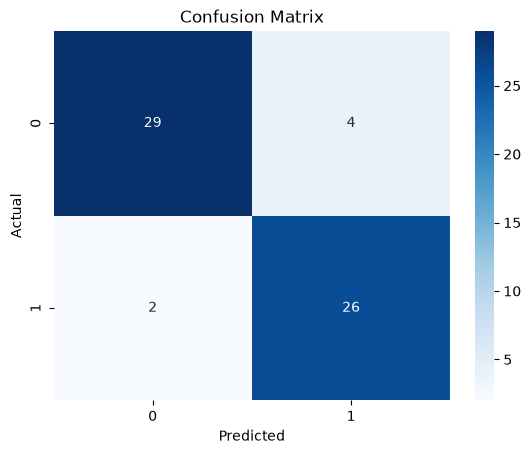

In [79]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [80]:
y_pred = rf.predict(X_test)
errors = X_test.copy()
errors['true'] = y_test
errors['pred'] = y_pred
errors['correct'] = (y_test == y_pred)
misclassified = errors[errors['correct'] == False]
print(f"Misclassified samples: {len(misclassified)} out of {len(X_test)}")
misclassified.head()

Misclassified samples: 6 out of 61


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,true,pred,correct
271,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0,6.0,0,1,False
196,69.0,1.0,1.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,2.0,1.0,3.0,0,1,False
33,59.0,1.0,4.0,135.0,234.0,0.0,0.0,161.0,0.0,0.5,2.0,0.0,7.0,0,1,False
66,60.0,1.0,3.0,140.0,185.0,0.0,2.0,155.0,0.0,3.0,2.0,0.0,3.0,1,0,False
92,62.0,1.0,3.0,130.0,231.0,0.0,0.0,146.0,0.0,1.8,2.0,3.0,7.0,0,1,False


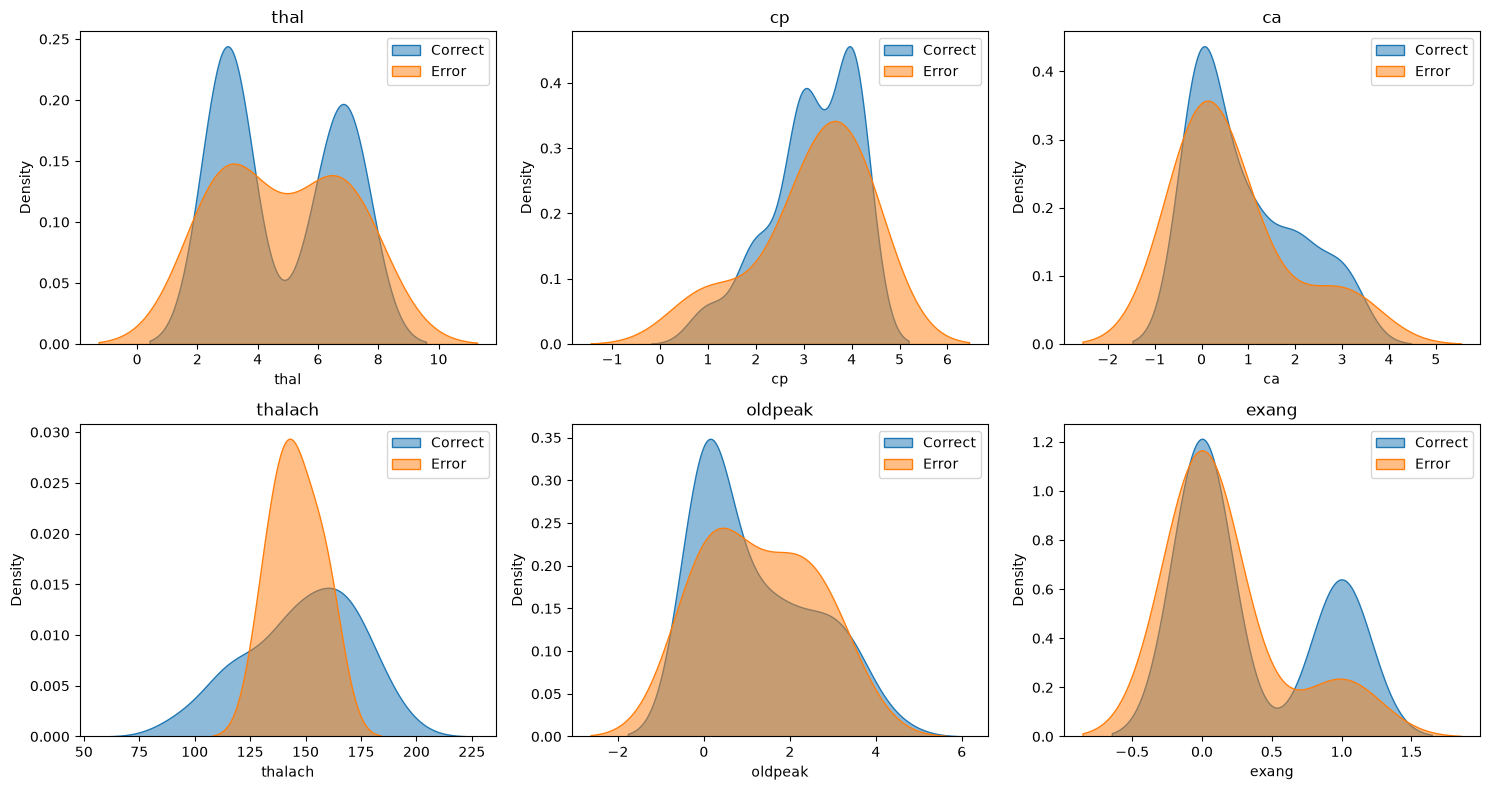

In [81]:
# Cell 13 - Compare feature distributions for correct vs incorrect predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
top_features = feat_imp.head(6).index
for i, feat in enumerate(top_features):
    sns.kdeplot(data=errors[errors['correct']==True], x=feat, label='Correct', ax=axes[i], fill=True, alpha=0.5)
    sns.kdeplot(data=errors[errors['correct']==False], x=feat, label='Error', ax=axes[i], fill=True, alpha=0.5)
    axes[i].set_title(feat)
    axes[i].legend()
plt.tight_layout()
plt.show()

In [82]:
feat_imp.head(6)

thal       0.198983
cp         0.140907
ca         0.116475
thalach    0.112057
oldpeak    0.094464
exang      0.063007
dtype: float64

## Hyperparameters Tuning

In [83]:
# from sklearn.model_selection import GridSearchCV

# params_rf = {
#     "n_estimators": [50, 100, 250, 300, 500],
#     "max_depth": [None, 5, 10, 20, 30],
#     "min_samples_split": [2, 5, 10, 15, 20]

# }

# grid_search = GridSearchCV(
#         estimator=rf,
#         param_grid = params_rf,
#         n_jobs=-1,
#         cv=5
# )

# grid_search.fit(X_train, y_train)

# grid_search.best_params_

In [84]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint

In [85]:
# param_dist = {
#     "n_estimators": randint(50,500),
#     "max_depth": [None, 3, 5, 10, 15, 20],
#     "min_samples_split": randint(2,11)
# }

In [86]:
# random_search = RandomizedSearchCV(
#     estimator = rf,
#             param_distributions = param_dist,
#             n_iter=10,
#             n_jobs= -1,
#             cv= 5
# )

In [87]:
# random_search.fit(X_train, y_train)

In [88]:
random_search.best_params_

NameError: name 'random_search' is not defined